# 드론 통신 방식
- 드론 통신 구조(WiFi 제어) 흐름 실습

---  


## 1부. 통신의 역사 — "어떻게 여기까지 왔을까?"

- 인류는 먼 거리에 정보를 전달하기 위해 끊임없이 기술을 발전시켜왔다. 
- 봉화에서 전신, 라디오, 인터넷을 거쳐 지금의 WiFi 드론 제어까지, 통신 기술의 흐름을 타임라인으로 먼저 살펴보자.
- <img src=attachment:31f22063-d45f-4c97-84ee-060b49533393.png width=1000>

---

## 2부. 통신의 기본 개념 — "데이터는 어떻게 이동할까?"

* 통신의 세 가지 핵심 개념
* **송신자(Sender) → 채널(Channel) → 수신자(Receiver)**
* 드론 제어에서는 <font color=red>스마트폰/노트북이 송신자</font>, <font color=green>WiFi 전파가 채널</font>, <font color=blue>드론이 수신자</font>

또한 통신 방향에 따라 세 가지 방식 있음

<span style="position:left;display:inline-block">

| 방식 | 설명 | 드론 예시 |
|------|------|-----------|
| 단방향 (Simplex) | 한 방향만 전송 | 구형 RC 조종기 → 드론 |
| 반이중 (Half-Duplex) | 번갈아 가며 송수신 | 무전기처럼 "오버" 후 교대 |
| 전이중 (Full-Duplex) | 동시에 송수신 | WiFi 드론: 명령 전송 + 영상 수신 동시에 |

</span>

<font color=blue><b>WiFi 드론은 전이중 방식이기 때문에 조종 명령을 보내면서 동시에 카메라 영상을 받아볼 수 있음</b></font>

---

## 3부. WiFi 통신의 구조 — "드론과 스마트폰이 대화하는 방법"

<h3>WiFi 드론 제어의 전체 통신 흐름 구조 다이어그램</h3>  
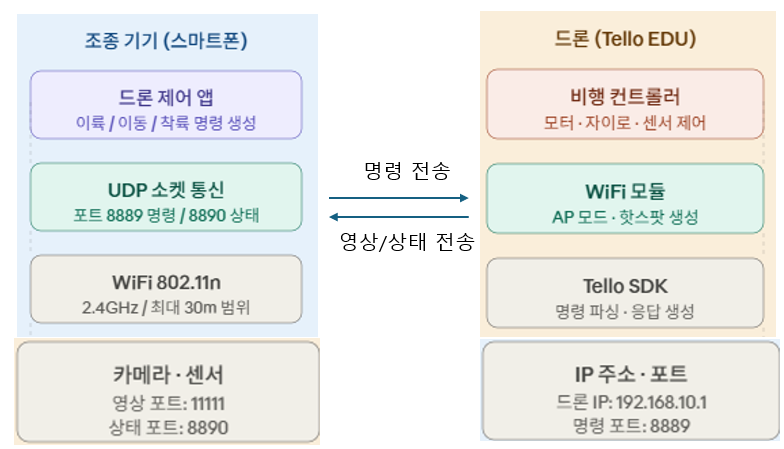  

---  

<h3>유선/무선 랜카드 종류</h3>  
<img src=attachment:cb4ce366-02a3-499e-96af-01d5740d535f.png style="border:1px solid blue;" width=800px>  

---  

<h3>랜카드 신호</h3>  

* NIC(Network Interface Card)에 부여되는 고유 식별 번호
* MAC주소(6바이트) : **00-00-00-00-00-00**
  > 앞 3바이트 : OUI(Organizationally Unique Identifier)로서 제조사 식별  
  > 뒤 3바이트 : NIC 고유번호로 제조사 내부적으로 부여하는 일련번호
* 랜카드가 유선인 경우 **이더넷**, 무선인 경우 **Wi-Fi**, 그외에도 **블루투스** 등이 있음
* <img src=attachment:a528af0d-bb92-4839-b339-48aca29d9f96.png>
  


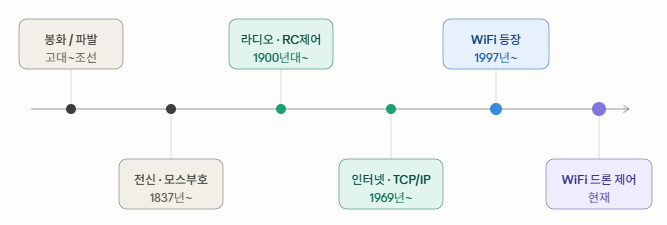
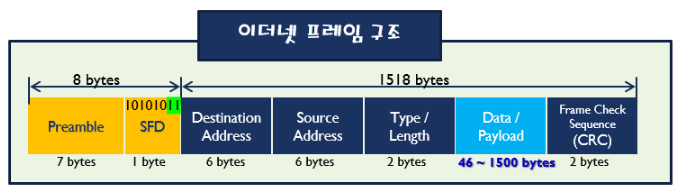
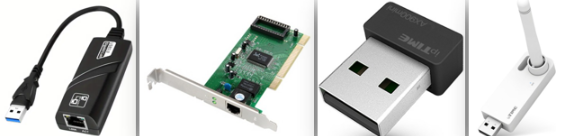

### 4부. Tello SDK 실전 명령어 — "파이썬으로 드론에게 말 걸기"

* 수업에서 사용할 핵심 개념 : UDP 소켓 통신
* Tello SDK 명령어 정리
- **선수조건**
  > (1) Tello EDU 드론/배터리 삽입/전원 켜기  
  > (2) 노트북과 드론 WiFi 페이링  

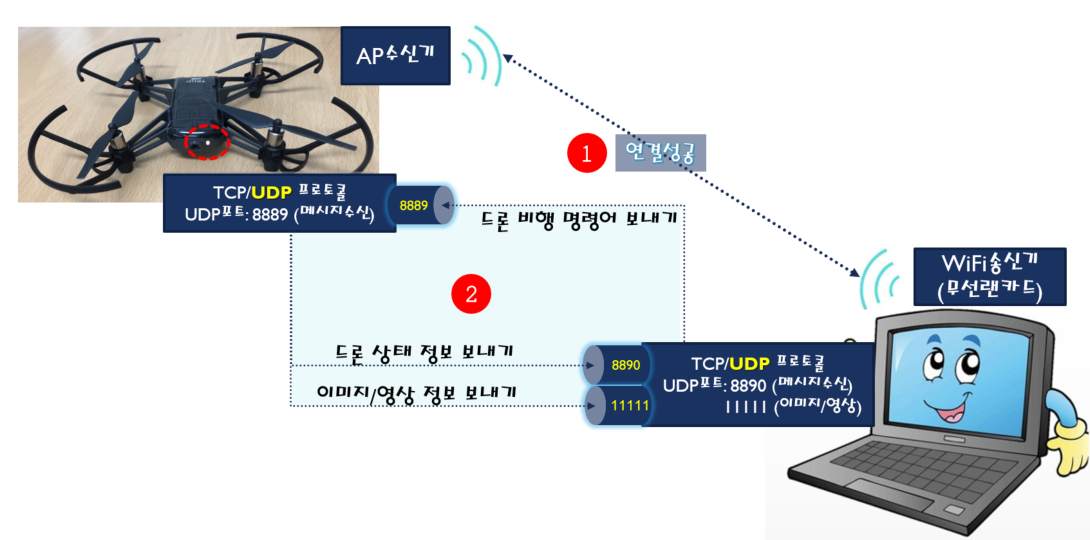  

---  

* 진행순서
* <img src=attachment:2c442fb2-eeeb-49a2-a834-5099cf7694b4.png> <img src=attachment:e4c9001b-e3f2-4eeb-93ff-78a448b32176.png> <img src=attachment:56cd46ae-78ec-4be8-b45f-8141bd497fdf.png> <img src=attachment:55940c72-050a-4c4d-8a58-47f37e82ca68.png> <img src=attachment:18100815-190b-4c6e-b8d3-f19034fe387d.png> <img src=attachment:30e3951e-3db2-4651-bc8e-97400d476a03.png>

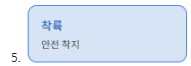
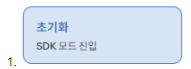
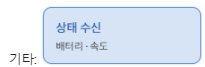
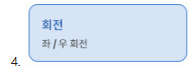
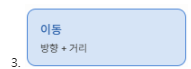
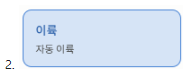

## TCP vs UDP 기본 개념 비교

<span style="position:left;display:inline-block;">

| 항목 | TCP | UDP |
|------|-----|-----|
| 연결 방식 | 연결 지향 (3-way handshake) | 비연결 |
| 신뢰성 | 높음 (전송 보장) | 낮음 (전송 보장 없음) |
| 속도 | 느림 | 빠름 |
| 순서 보장 | O | X |
| 용도 | HTTP, FTP, 채팅 | 게임, 스트리밍, DNS |
| 소켓 타입 | <font color=red><b>SOCK_STREAM</b></font> | <font color=red><b>SOCK_DGRAM</b></font> |

</span>

---

## TCP vs UDP 코드 흐름 비교

```
====================TCP통신===============================

 TCP 서버                      TCP 클라이언트
─────────────────────         ─────────────────────
socket()                      socket()
bind()                        
listen()                      
accept()   ← 연결 대기         connect()  ← 연결 필수
recv()                        send()  
send()                        recv()
close()                       close()

====================UDP통신===============================

 UDP 서버                      UDP 클라이언트
─────────────────────         ─────────────────────
socket()                      socket()
connect()  ← 연결 필수         
recvfrom()                    sendto()     ← 바로 전송
sendto()                      recvfrom()   ← 바로 전송
close()                       close()

========================================================
```

---

## 언제 무엇을 쓸까?

```
TCP 사용 ✅               UDP 사용 ✅
─────────────────         ─────────────────
웹 서버 / API             실시간 게임
파일 전송                 영상 스트리밍
로그인 / 인증             DNS 조회
채팅 앱                   IoT 센서 데이터
이메일 (SMTP)             음성 통화 (VoIP)
```

<a href="tcp-server.ipynb" target=_blank alt=TCP><font color=blue><b>■ TCP 서버</b></font></a>  
<a href="tcp-client.ipynb" target=_blank alt=TCP><font color=blue><b>■ TCP 클라이언트</b></font></a>  

---  

<a href="tcp-server.ipynb" target=_blank alt=TCP><font color=blue><b>■ UDP 서버</b></font></a>  
<a href="tcp-client.ipynb" target=_blank alt=TCP><font color=blue><b>■ UDP 클라이언트</b></font></a>  

---


<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  &ensp;<h2>여기서부터는 Tello 드론과 노트북으로 연결하여 작업하기</h2>
</div>

1. 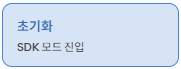

In [ ]:
# 선수작업: 
#   1. 드론 배터리 삽입
#   2. 드론과 노트북 WiFi 페이링 완료
#
# (중요) 선수작업 완료 후 아래 코드 실행:   UDP 소켓 생성 > "command" 전송하여 드론 SDK모드 활성화 진행
# 드론 IP: 192.169.10.1, PORT: 8889
import socket

# UDP 소켓 생성 : 
sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM) 
sock.bind(('', 9000))  # 내 수신 포트

DRONE_IP = '192.168.10.1'
DRONE_PORT = 8889

def send(cmd):
    sock.sendto(cmd.encode(), (DRONE_IP, DRONE_PORT))
    resp, _ = sock.recvfrom(1024)
    return resp.decode()

# SDK 모드 진입 (반드시 먼저!)
print(send('command'))  # 응답: 'ok'

2. <img src=attachment:e9bfd59b-f907-49aa-b4b5-70338f298243.png>
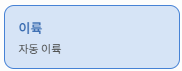

In [ ]:
# "takeoff" 명령 전송하여 드론 이륙
response = send('takeoff')
print(f"이륙 응답: {response}")
# 출력: 이륙 응답: ok

# 잠깐 공중에 머무르기
import time
time.sleep(3)  # 3초 대기

3. <img src=attachment:1f994326-059a-475a-abb5-29204bb8e76d.png>
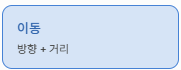

In [ ]:
# 방향 명령: up/down/left/right/forward/back
# 앞으로 30cm 이동
send('forward 30')

# 오른쪽으로 30cm
send('right 30')

# 위로 50cm 상승
send('up 50')

# 여러 동작을 순서대로 실행
commands = ['left 30', 'back 30',
            'down 30', 'right 30']
for cmd in commands:
    send(cmd)
    time.sleep(1.5)  # 각 동작 완료 대기

4. <img src=attachment:59bec79c-9979-48b9-8d3f-244228d05723.png>
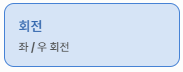

In [ ]:
# 회전 명령: cw(시계방향), ccw(반시계방행) 0 ~ 360
# 시계 방향으로 90도 회전
send('cw 90')
time.sleep(1)

# 반시계 방향으로 45도 회전
send('ccw 45')
time.sleep(1)

# 제자리에서 한 바퀴 회전
send('cw 315')
time.sleep(3)

5. <img src=attachment:9600159c-a4a2-487b-801f-4a20e23aba21.png>
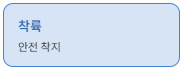

In [ ]:
# 착륙 명령: land
# 정상 착륙
response = send('land')
print(f"착륙 응답: {response}")
# 출력: 착륙 응답: ok

# 비상 정지 (주의: 추락할 수 있음!)
# send('emergency')

# 소켓 정리
sock.close()

기타: <img src=attachment:d37a5715-baff-4af6-a4db-ae79e1b52f7e.png>
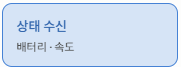

In [ ]:
# 드론 상태 수신(8890) : 드론은 1초마다 상태 정보를 8890포트로 자동 전송하여 배터리, 속도, 높이 등 상태를 보고
import threading

STATUS_PORT = 8890
status_sock = socket.socket(socket.AF_INET,
                            socket.SOCK_DGRAM)
status_sock.bind(('', STATUS_PORT))

def recv_status():
    while True:
        data, _ = status_sock.recvfrom(1024)
        info = data.decode()
        # 예시: "bat:85;h:30;vgx:0;..."
        items = dict(x.split(':')
                     for x in info.split(';')
                     if ':' in x)
        print(f"배터리: {items.get('bat')}%,"
              f" 높이: {items.get('h')}cm")

t = threading.Thread(target=recv_status,
                     daemon=True)
t.start()

<div style="background-color: #f9f9a9; padding: 2px; border-radius: 1px;">
  <h2>5부. 관련 도구 소개 : Packet Sender</h2>
</div>


---

<span style="position:left;display:inline-block;">

<table>
    <tr>
        <td><img src=attachment:cdb2309d-c2df-4092-804e-ed286b11136c.png><br><a><b><font color=blue>Droneblocks</font></b> 앱 다운로드</a></td>
        <td><a href=https://www.python.org/ alt="Python다운로드"><img src=attachment:d6d8a882-e156-4d7b-9318-4f32ae345607.png></a></td>
        <td><img src=attachment:c02f39f5-ce10-4950-8703-fdc0a2498f57.png></td>
    </tr>
    <tr>
        <td><a href=https://www.wireshark.org/download.html><img src=attachment:0ca36e13-149c-4d81-bf48-5eef9b6ee940.png></a></td>
        <td><a href=https://packetsender.com/ alt="PacketSender다운로드"><img src=attachment:b3b57375-b8d5-464a-aaa4-d6fba5b47839.png style="border:2px solid red;"></a></td>
        <td><img src=attachment:f7090793-5a0c-4035-b555-7fa49a2d8803.png></td>
    </tr>    
</table>

</span>
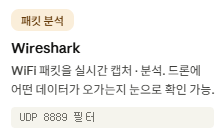
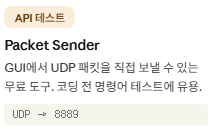
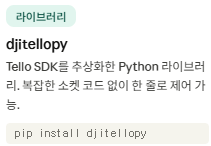
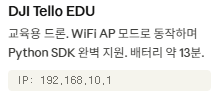
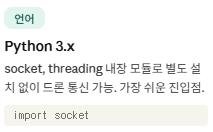
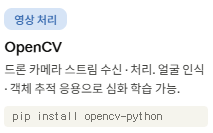

## 1단계: Packet Sender 설치

<span style="position:left;display:inline-block;">

<table>
    <tr>
      <td align=left><img src=attachment:bda2ad94-1ef2-4739-82e3-4e33907f217c.png></td>
      <td><a href=https://packetsender.com/downloads alt="Packet Sender 다운로드"><img src=attachment:254ed22b-da0e-4e22-a292-fbc15b0ead05.png></a></td>
    </tr>
    <tr>
      <td align=left><img src=attachment:a4450830-8c82-47a2-8016-f0edc0ab9866.png></td>
      <td><img src=attachment:ccc24449-5436-4786-aa57-45416f6e5efa.png></td>
    </tr>
    <tr>
      <td align=left><img src=attachment:adc4ec04-6673-458f-844c-d7e668ceed5e.png></td>
      <td><img src=attachment:feececb5-59b9-464c-8a39-e924d812aba9.png><br>
          <img src=attachment:f0b9f332-6942-417c-92a8-c37eafb5920c.png width=600>
      </td>
    </tr>
    <tr>
      <td align=left><img src=attachment:ee023e76-7cba-4476-9101-641001ef4061.png></td>
      <td><img src=attachment:50f80371-3111-4b07-9811-377b5541475a.png>
      </td>
    </tr>
</table>
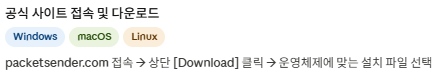
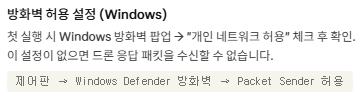
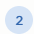
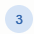
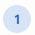
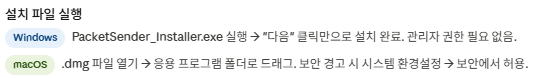
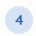
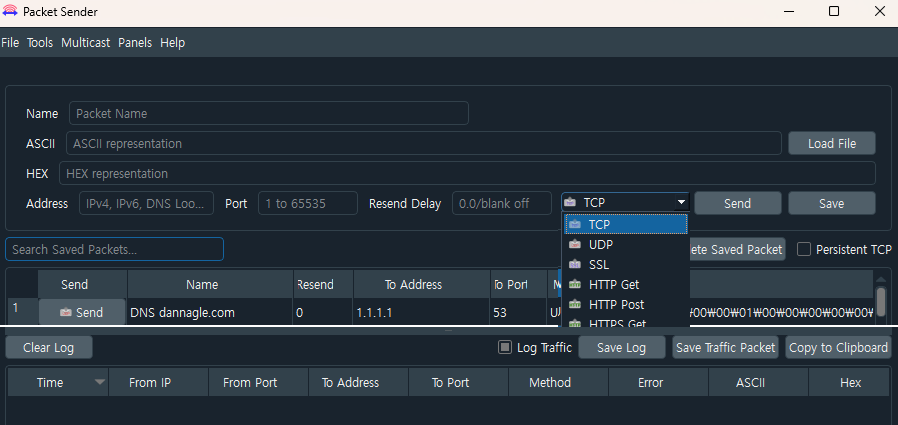
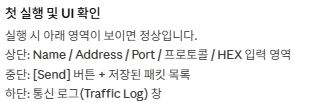

## 2단계: Tello 드론 WiFi연결
<img src=attachment:7e5b3d56-19ec-4890-97da-4ccc4301af3d.png style="border:1px solid blue;" width=800px>  

### **연결 순서:**

1. Tello 전원 버튼 1회 누름 → 전면 LED가 노란색으로 빠르게 깜박이면 AP 생성 완료
2. PC WiFi 목록에서 TELLO-XXXXXX 선택 → 클릭
3. 연결 후 ping 192.168.10.1 로 통신 확인
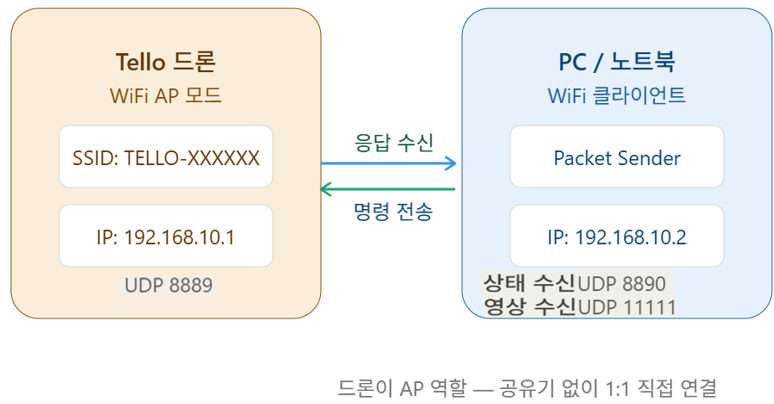

## 3단계: Packet Sender 화면 구성 및 SDK진입
<img src=attachment:98e8b2f5-73f6-4f4f-a9d9-b91de34ed9df.png style="border:1px solid blue;" width=800px>
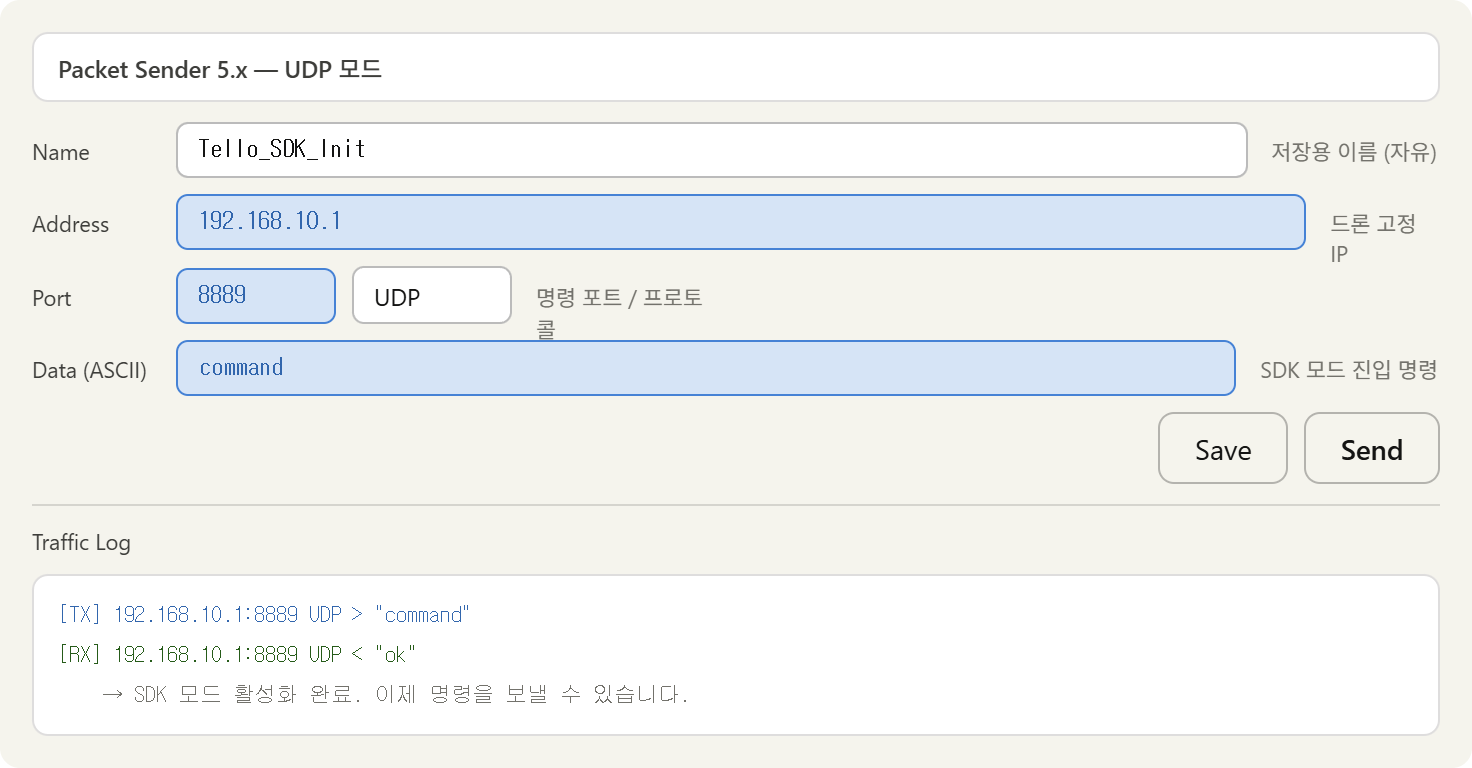

## 4단계: SDK버전 확인 및 상태 정보 조회
위 **command** 전송 후 아래의 명령을 전송합니다.   
* **sdk?**
  > SDK 버전 확인
* **sn?**
  > 시리얼 번호
* **battery?**
  > 배터리 잔량
* **speed?**
  > 현재 속도
* **time?**
  > 비행 누적 시간
* **wifi?**
  > WiFi SNR

---  

* <a href=https://dl-cdn.ryzerobotics.com/downloads/Tello/Tello%20SDK%202.0%20User%20Guide.pdf target=_blank>Tello SDK 사용자 매뉴얼</a>
* 기본 모드(1:1): Tello AP의 새이름 및 비밀번호 설정하기
  > 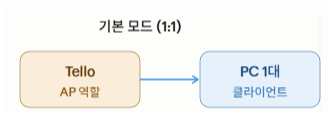  
  > **wifi Tello_SW07 7777----**

## 5단계: AP환경 구성 - 여러 대의 드론을 동시에 제어할 때
* 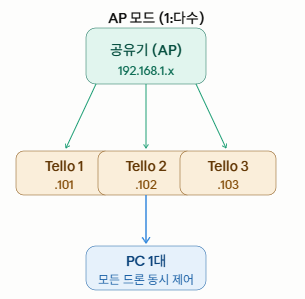
* AP모드에서 Station모드로 전환 절차  
  > 1. 드론과 1:1 연결 후  
  > 2. Packet Sender에서 전송:  
  >    **command 전송 → ok 수신**  
  >    **ap 실습실_SSID 비밀번호**  
  > 3. 드론 LED가 흰색으로 바뀌며 재부팅  
  > 4. 공유기 DHCP 목록에서 드론 IP 확인  
  > 5. 이후 해당 IP로 Packet Sender 연결
* 군집 비행시에 알아야할 중요한 정보: sn, 드론의SSID, MAC 
* 드론 MAC 확인 방법: 드론과 노트북 연결 후 명령프롬프트에서 `arp -a` 하여 192.168.10.1의 MAC 주소 확인
* 참고사항: [군집비행 파이썬 코드 다운로드](https://github.com/TelloSDK/Multi-Tello-Formation)

## 6단계: 드론 제어 
<span style="position:left;display:inline-block;">

<table>
    <tr align=left>
        <td>
            <img src=attachment:4b54418c-9f26-4347-8c7f-9953e6a83910.png>
        </td>
    </tr>
    <tr align=left>
        <td>
            <img src=attachment:5eb09d3f-2614-4640-97e3-4337476938ee.png>
        </td>
    </tr>
    <tr align=left>
        <td>
            <img src=attachment:e960990a-3524-4c8b-8d97-fda0cf3b0e30.png>
        </td>
    </tr>
    <tr align=left>
        <td>
            <img src=attachment:464dfd27-c004-4ed0-aa11-55b4f36727ba.png><br>
            <b>
            forward 50<br>
            cw 180<br>
            up 50<br>
            forward 50<br>
            down 50<br>
            ccw 180<br>            
            </b>
        </td>
    </tr>
    <tr align=left>
        <td>
            <img src=attachment:2db43666-3989-41f9-8acd-c49bf8f1d904.png><br>
            <font color=red>드론에서 배터리를 분리</font>
        </td>
    </tr>
</table>

</span>
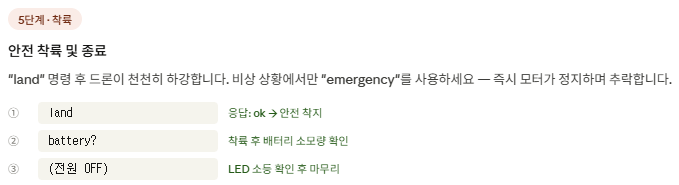
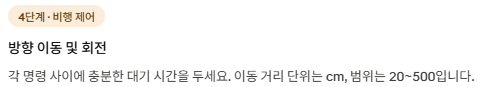
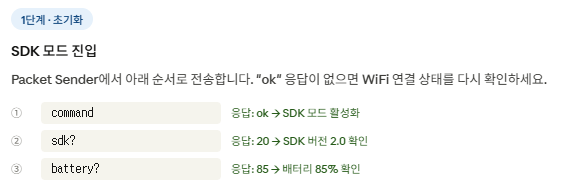
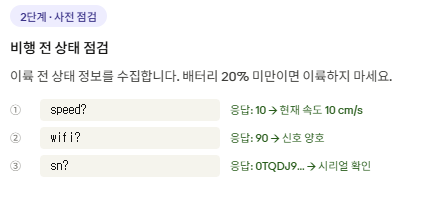
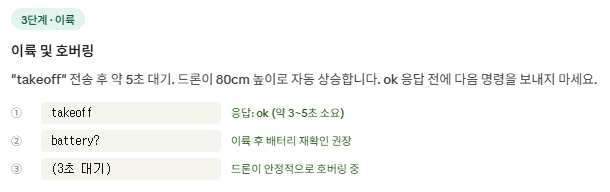

### 핵심 정리

**오늘 배운 핵심 3가지**

1. 모든 통신은 **송신 → 채널 → 수신**의 구조를 가지며, WiFi 드론은 전이중 방식으로 명령과 데이터를 동시에 주고받는다.
2. Tello EDU드론은 WiFi AP 모드로 동작하며, **UDP 소켓 + 포트 번호**로 명령/상태/영상을 구분한다.
3. `socket.sendto()`로 문자열 명령을 보내면 드론이 파싱해 모터를 제어한다.
